# Financial Networks - Python Small Scale Prototyping

In [ ]:
import sys
sys.path.append('..')
import yfinance as yf
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx

from py_scripts.project1 import mst, analysis, contagion

window=60

tickers = [
    #tech & semi (the core contagion group)
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'AVGO', 'AMD', 'QCOM',
    #finance (the banking cluster)
    'JPM', 'BAC', 'GS', 'MS', 'V', 'MA',
    #healthcare (defensive cluster)
    'LLY', 'UNH', 'JNJ', 'PFE',
    #energy & industrials (cyclical cluster)
    'XOM', 'CVX', 'CAT', 'HON', 'GE',
    #consumer & retail (stability)
    'COST', 'WMT', 'PG', 'PEP', 'KO'
]

data = yf.download(tickers, start="2023-01-01", progress=False)['Close']

fig = px.line(data, x=data.index, y=data.columns,
              title='10 Tech Stocks Close Price (Since 2023)',
              labels={'value': 'Close Price (USD)', 'variable': 'Ticker'})
fig.update_layout(xaxis_title='Date', yaxis_title='Price (USD)')
fig.show()


### Marchenko-Pastur Filtering on Returns

In [51]:
#NOISE FILTERING THE DATA
returns = np.log(data / data.shift(1)).dropna()

fig = px.line(returns, x=returns.index, y=returns.columns,
              title='10 Tech Stocks Returns (Since 2023)',
              labels={'value': 'Returns', 'variable': 'Ticker'})
fig.update_layout(xaxis_title='Date', yaxis_title='Returns')
fig.show()

In [52]:
trees = []



for i in range(window, len(returns)):
    window_slice = returns.iloc[i-window : i]
    current_date = returns.index[i]
    clipped_corr_matrix = mst.clipping(window_slice, window)
    curr_tree = mst.mst(clipped_corr_matrix)           
    trees.append((current_date, curr_tree))

df_trees = pd.DataFrame(trees, columns=['Date', 'MST'])

c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in sqrt
  result = func(self.values, **kwargs)
c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in sqrt
  result = func(self.values, **kwargs)
c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in sqrt
  result = func(self.values, **kwargs)
c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in sqrt
  result = func(self.values, **kwargs)
c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\

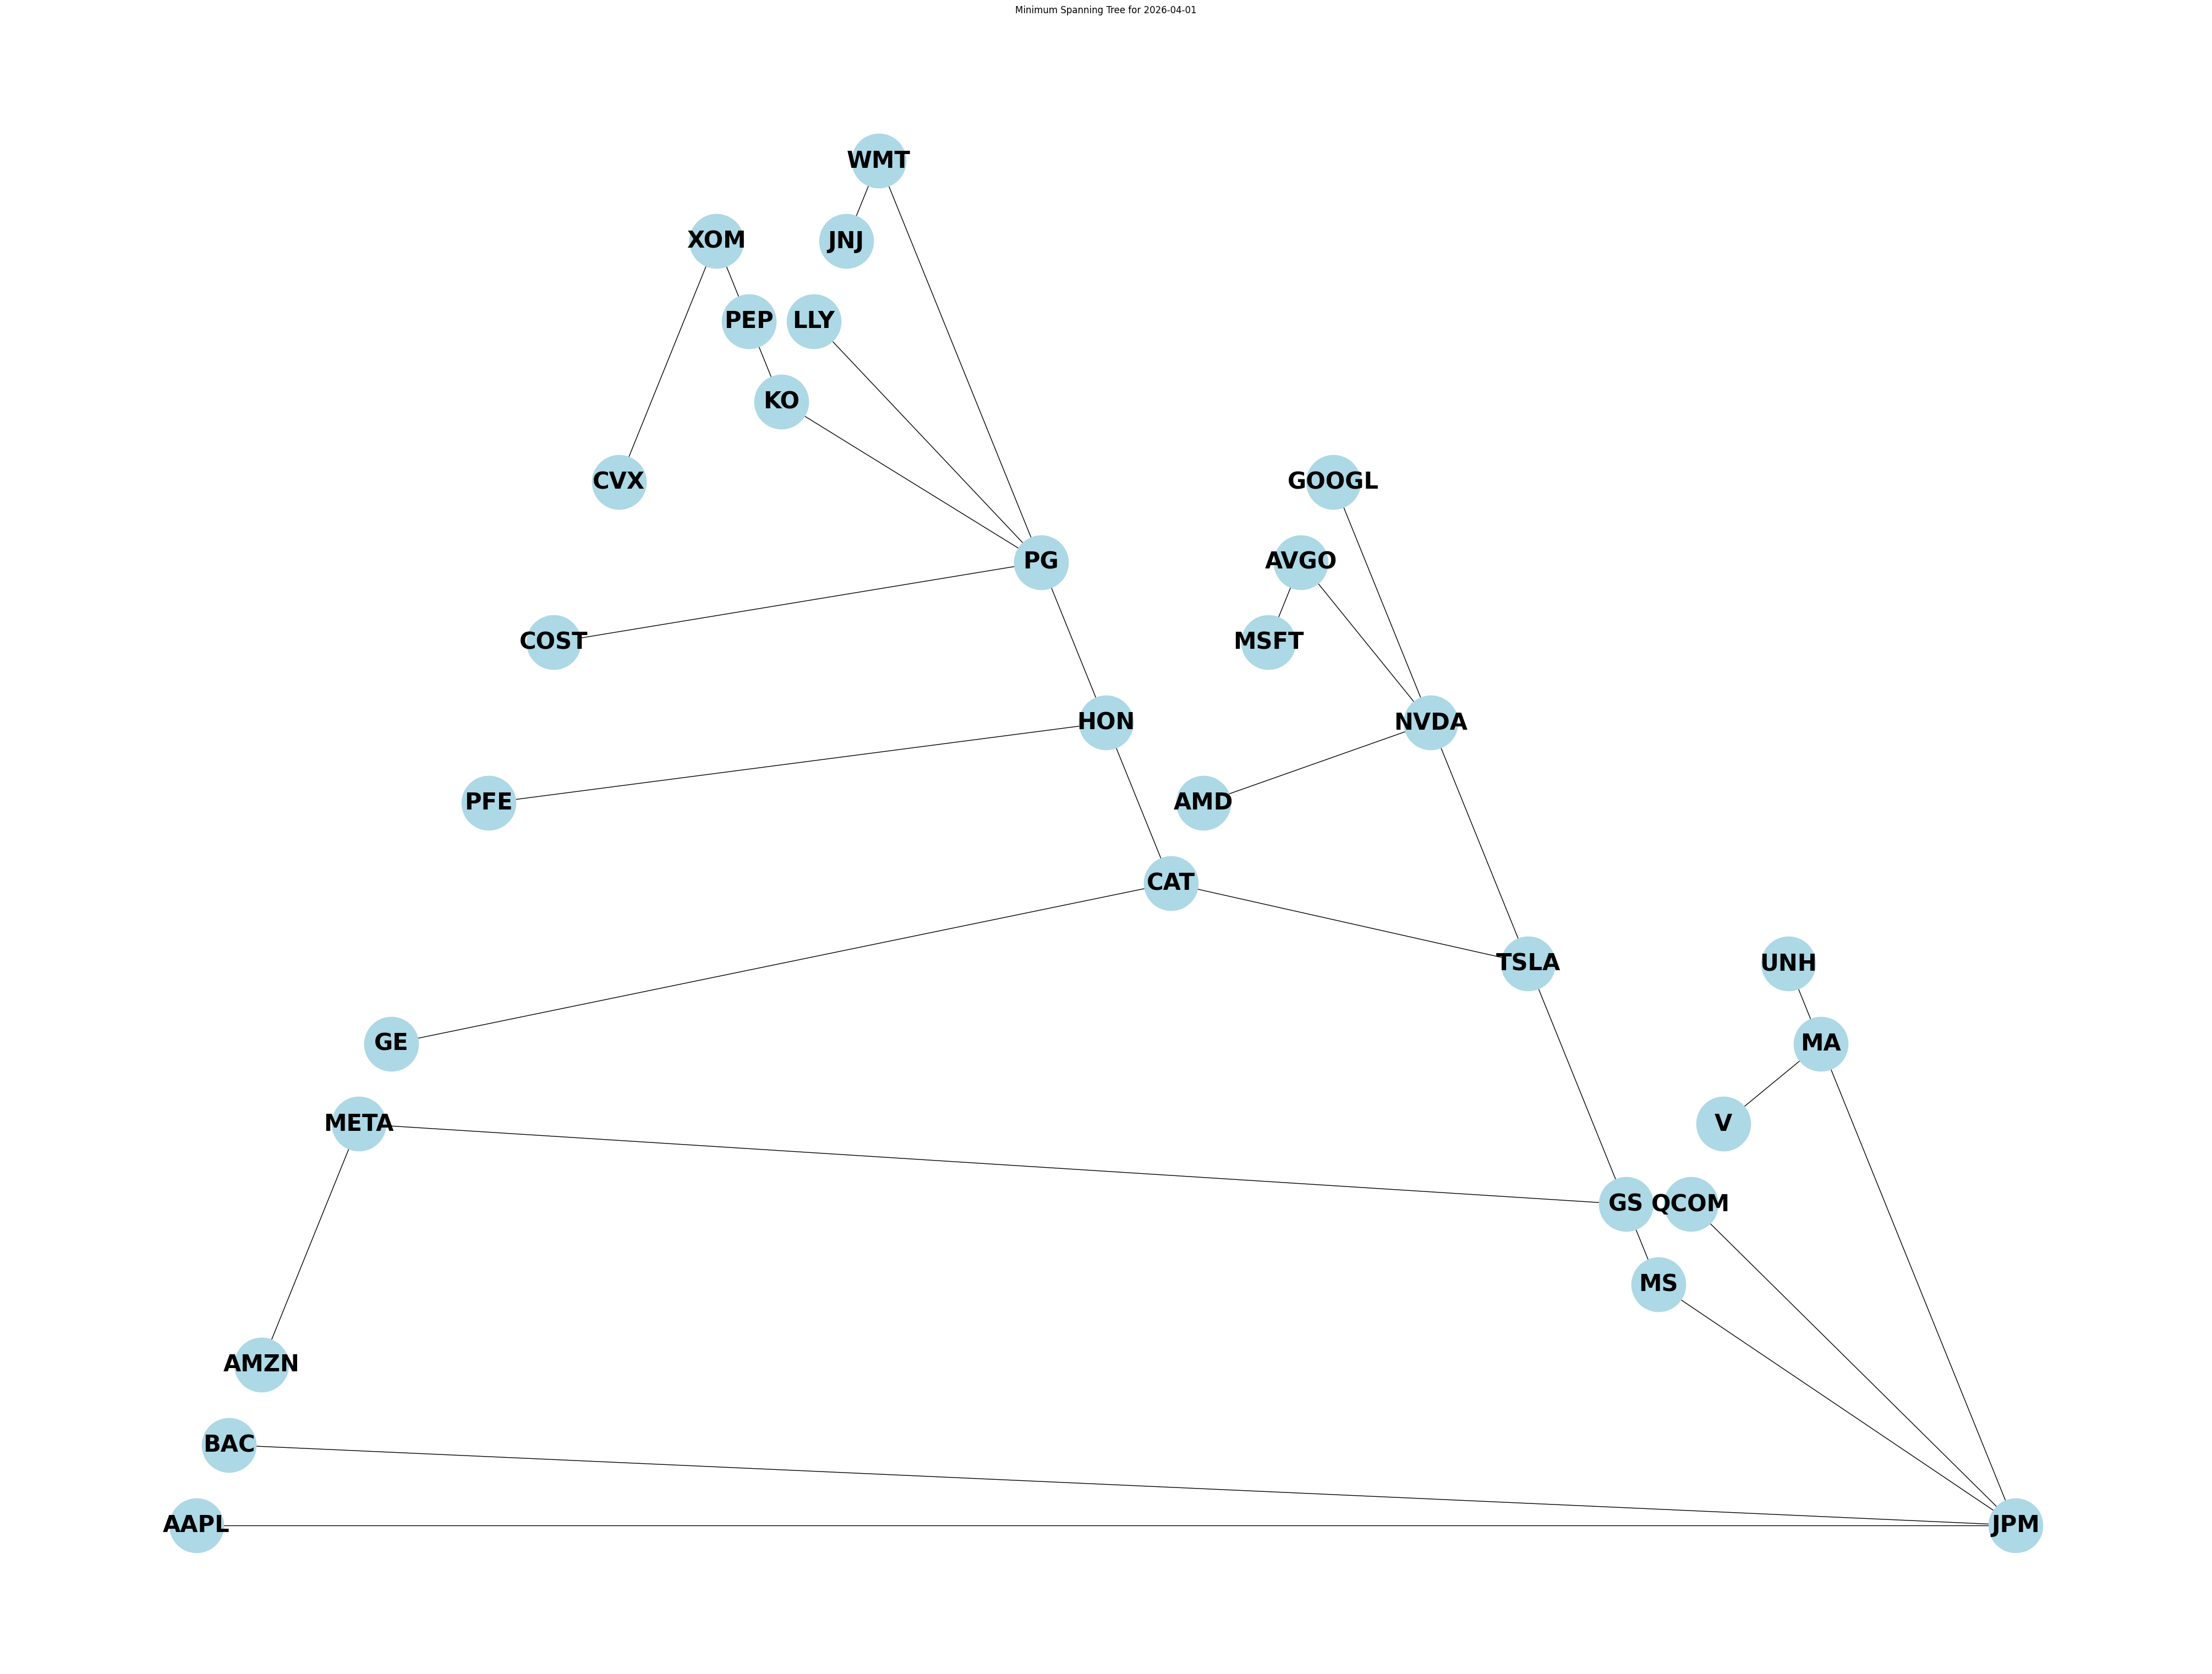

In [53]:

last_mst = df_trees['MST'].iloc[-1]
pos = nx.planar_layout(last_mst)  #positions for all nodes

plt.figure(figsize=(40, 30))
nx.draw(last_mst, pos, with_labels=True, node_color='lightblue', node_size=5000, font_size=30, font_weight='bold')
plt.title(f'Minimum Spanning Tree for {df_trees["Date"].iloc[-1].date()}')
plt.show()

In [54]:
degrees = dict(last_mst.degree())
hub_node = max(degrees, key=degrees.get)
print(f"The Hub of the Star is: {hub_node}")
print(returns[hub_node].iloc[i-window: i].head())
print(returns[hub_node].iloc[i-window: i].describe())

The Hub of the Star is: JPM
Date
2026-01-05    0.025960
2026-01-06    0.006205
2026-01-07   -0.023036
2026-01-08    0.008527
2026-01-09   -0.001821
Name: JPM, dtype: float64
count    60.000000
mean     -0.001611
std       0.016622
min      -0.043132
25%      -0.012150
50%       0.000251
75%       0.008628
max       0.038705
Name: JPM, dtype: float64


The graph makes sense, but we can see some odd edges like the AAPL and QCOM (Tech) linked to JPM (Finance).
Those links are likely due to the noisy nature of a 60 days window data this tree was built upon.

SHOCK PROPAGATION SIMULATION

In [55]:
nvda_shock = contagion.simulate_shock(last_mst, 'NVDA', -0.10)

Shock event with magnitude -0.1 occurred!


In [56]:
sorted_impacts = dict(sorted(nvda_shock.items(), key=lambda x: x[1]))
print("Top Stocks impacted by an NVDA 10% drop:")

for ticker, val in list(sorted_impacts.items()):
    if ticker != 'NVDA':
        print(f"{ticker}: {val*100:.1f}%")

Top Stocks impacted by an NVDA 10% drop:
AVGO: -5.4%
TSLA: -5.1%
AMD: -5.0%
GOOGL: -3.8%
GS: -2.4%
CAT: -2.3%
MSFT: -1.7%
MS: -1.3%
META: -1.1%
GE: -1.1%
HON: -1.1%
JPM: -0.7%
AMZN: -0.5%
BAC: -0.4%
PFE: -0.3%
QCOM: -0.3%
PG: -0.3%
MA: -0.3%
AAPL: -0.3%
V: -0.2%
WMT: -0.2%
KO: -0.2%
COST: -0.1%
LLY: -0.1%
PEP: -0.1%
UNH: -0.1%
JNJ: -0.1%
XOM: -0.0%
CVX: -0.0%


We've successfully simulated a shock contagion model on a small scale of stocks.